# Analyse des données du baccalauréat en France

Ce notebook analyse les données du baccalauréat en France à partir des résultats par académie.  
Grâce à un EDA (fait sur ce notebook dédié), un preprocessing et plusieur modélisation de Machine Learning  
pour prédire la mention elle-même, la propotion des mentions ou la mention majoritaire.  
(un notebook par souhait de prédiction)

## Import + configuation

In [53]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## Chargement des données

In [54]:
path= '../data/fr-en-baccalaureat-par-academie.csv'
df = pd.read_csv(path, delimiter=';')

## Fonction utilitaire

Fonction pour nettoyer le nom des colonnes, réduire la longueurs des noms  
 pour une meilleur lisibilité.

In [55]:
def snakecase_app(value):
    if isinstance(value,str):
        return (
            value.strip()
            .lower()
            .replace(' ', '_')
            .replace("'","_")
            .replace('é','e')
            .replace('ô','o')
        )
    else:
        return (
            value.str.strip()
            .str.lower()
            .str.replace(' ', '_')
            .str.replace("'","_")
            .str.replace(',','')
            .str.replace('é','e')
            .str.replace('ô','o')
            .str.replace('nombre_de_','')
            .str.replace('nombre_d_','')
            .str.replace('admis_avec_','')
            .str.replace('_du_jury','')
            .str.replace('2nd_groupe','rattrapage')
            .str.replace('à_l_issue_du','au')
            .str.replace('admis_sans_mention','sans_mention')
            .str.replace('libelle_academie','academie')
        )

## Audit qualité

In [56]:
# Basic stats
print(f'Number of rows : {df.shape[0]}')
print(f'Number of columns : {df.shape[1]}\n')

print('Display of dataset: ')
display(df.head())

print('Basics statistics :')
data_desc = df.describe(include='all')
display(data_desc)

print('Percentage of missing values: ')
display(100 * df.isnull().sum() / df.shape[0])

missing_values = df.isnull().any().any()
if missing_values :
    print('There are missing values in the dataset')
else :
    print('There are no missing values in the dataset')

print('\nCheck data type: ')
display(df.info())

Number of rows : 43217
Number of columns : 22

Display of dataset: 


,Session,Code académie,Libellé académie,Sexe,Statut du candidat,Voie,Série,Diplôme spécialité,Nombre d'inscrits,Nombre de présents,Nombre d'admis au 1er groupe,Nombre de refusés au 1er groupe,"Nombre d'ajournés, passant les épreuves du 2nd groupe",Nombre d'admis à l'issue du 2nd groupe,Nombre de refusés à l'issue du 2nd groupe,Nombre d'admis totaux,Nombre d'admis avec mention TB avec les félicitations du jury,Nombre d'admis avec mention TB sans les félicitations du jury,Nombre d'admis avec mention B,Nombre d'admis avec mention AB,Nombre d'admis sans mention,Nombre de refusés totaux
0,2021,4,BORDEAUX,FEMININ,SCOLAIRE,BAC PROFESSIONNEL,BAC PRO SERV,BAC PRO 33004 ACC.SOINS-S.PERS. OPT.EN STRUCTUR,471,470,449,13,8,4,4,453,0,29,164,170,90,17
1,2021,4,BORDEAUX,FEMININ,SCOLAIRE,BAC PROFESSIONNEL,BAC PRO SERV,BAC PRO 34304 HYGIENE PROPRETE STERILISATION,10,10,7,3,0,0,0,7,0,0,0,5,2,3
2,2021,4,BORDEAUX,FEMININ,SCOLAIRE,BAC PROFESSIONNEL,BAC PRO SERV,BAC PRO AG 33002 SERV PERS TERRIT,419,409,394,15,0,0,0,394,0,22,76,142,154,15
3,2021,4,BORDEAUX,FEMININ,SCOLAIRE,BAC TECHNOLOGIQUE,BAC STD2A,BAC STD2A SCIENCES & TECHNO. DESIGN-ARTS APPLI...,178,178,174,0,4,2,2,176,2,10,70,69,25,2
4,2021,4,BORDEAUX,FEMININ,SCOLAIRE,BAC TECHNOLOGIQUE,BAC STL,BAC STL BIOCHIM.-BIOLOGIE-BIOTECHNOL.,143,143,138,0,5,4,1,142,0,9,27,49,57,1


Basics statistics :


,Session,Code académie,Libellé académie,Sexe,Statut du candidat,Voie,Série,Diplôme spécialité,Nombre d'inscrits,Nombre de présents,Nombre d'admis au 1er groupe,Nombre de refusés au 1er groupe,"Nombre d'ajournés, passant les épreuves du 2nd groupe",Nombre d'admis à l'issue du 2nd groupe,Nombre de refusés à l'issue du 2nd groupe,Nombre d'admis totaux,Nombre d'admis avec mention TB avec les félicitations du jury,Nombre d'admis avec mention TB sans les félicitations du jury,Nombre d'admis avec mention B,Nombre d'admis avec mention AB,Nombre d'admis sans mention,Nombre de refusés totaux
count,43217.00,43217.00,43217,43217,43217,43217,43217,43217,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00,43217.00
unique,NaN,NaN,30,4,5,3,23,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NANTES,MASCULIN,SCOLAIRE,BAC PROFESSIONNEL,BAC PRO PROD,BAC GENE 10019 BAC GENERAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1972,19307,23133,34830,18359,715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023.03,17.57,NaN,NaN,NaN,NaN,NaN,NaN,86.35,85.84,74.29,5.28,6.27,4.38,1.89,78.67,0.83,6.77,16.89,26.37,27.80,7.17
std,1.41,14.36,NaN,NaN,NaN,NaN,NaN,NaN,647.27,647.23,596.79,17.80,44.63,31.97,12.99,624.65,11.84,80.73,161.85,202.24,179.02,28.38
min,2021.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2022.00,9.00,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2023.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,8.00,7.00,6.00,1.00,0.00,0.00,0.00,6.00,0.00,0.00,1.00,2.00,2.00,1.00
75%,2024.00,23.00,NaN,NaN,NaN,NaN,NaN,NaN,29.00,28.00,23.00,4.00,1.00,1.00,0.00,24.00,0.00,1.00,5.00,8.00,10.00,4.00


Percentage of missing values: 


Session                                                         0.00
Code académie                                                   0.00
Libellé académie                                                0.00
Sexe                                                            0.00
Statut du candidat                                              0.00
Voie                                                            0.00
Série                                                           0.00
Diplôme spécialité                                              0.00
Nombre d'inscrits                                               0.00
Nombre de présents                                              0.00
Nombre d'admis au 1er groupe                                    0.00
Nombre de refusés au 1er groupe                                 0.00
Nombre d'ajournés, passant les épreuves du 2nd groupe           0.00
Nombre d'admis à l'issue du 2nd groupe                          0.00
Nombre de refusés à l'issue du 2nd

There are no missing values in the dataset

Check data type: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43217 entries, 0 to 43216
Data columns (total 22 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Session                                                        43217 non-null  int64 
 1   Code académie                                                  43217 non-null  int64 
 2   Libellé académie                                               43217 non-null  object
 3   Sexe                                                           43217 non-null  object
 4   Statut du candidat                                             43217 non-null  object
 5   Voie                                                           43217 non-null  object
 6   Série                                                          43217 non-null  object
 7   Diplô

None

Vérification des valeurs uniques pour chaque colonne catégorielles pour vérifier les  
doublons de nom et faire un mapping si nécessaire.

In [57]:
for column in df.columns.to_list():
    if df[column].dtypes == 'object':
        print(f'{column} : \n{df[column].unique()}')

Libellé académie : 
['BORDEAUX' 'CLERMONT-FERRAND' 'CORSE' 'CRETEIL' 'DIJON' 'GRENOBLE'
 'GUADELOUPE' 'GUYANE' 'LA REUNION' 'LILLE' 'LIMOGES' 'LYON' 'MARTINIQUE'
 'MAYOTTE' 'MONTPELLIER' 'AIX-MARSEILLE' 'AMIENS' 'BESANCON' 'NANCY-METZ'
 'NANTES' 'NICE' 'NORMANDIE' 'ORLEANS-TOURS' 'PARIS' 'POITIERS' 'REIMS'
 'RENNES' 'STRASBOURG' 'TOULOUSE' 'VERSAILLES']
Sexe : 
['FEMININ' 'MASCULIN' 'GARCONS' 'FILLES']
Statut du candidat : 
['SCOLAIRE' 'APPRENTISSAGE' 'ENSEIGNEMENT A DISTANCE' 'INDIVIDUEL'
 'FORMATION CONTINUE']
Voie : 
['BAC PROFESSIONNEL' 'BAC TECHNOLOGIQUE' 'BAC GENERAL']
Série : 
['BAC PRO SERV' 'BAC STD2A' 'BAC STL' 'BAC STMG' 'BAC PRO PROD' 'BAC ST2S'
 'BAC STI2D' 'BAC GENERAL' 'BAC STAV' 'BAC STHR' 'BAC S2TMD' 'STMG'
 'BAC PRO PRODUCTION AGRI' 'BAC PRO PRODUCTION MEN'
 'BAC PRO SERVICES AGRI' 'BAC PRO SERVICES MEN' 'STAV' 'STD2A' 'GENERALE'
 'STHR' 'STI2D' 'ST2S' 'STL']
Diplôme spécialité : 
['BAC PRO 33004 ACC.SOINS-S.PERS. OPT.EN STRUCTUR'
 'BAC PRO 34304 HYGIENE PROPRETE STER

## Nettoyage des données

Application de la fonction créée pour nettoyage

In [58]:
df.columns = snakecase_app(df.columns)

Application de la fonction créée pour nettoyage des valeurs catégorielles

In [59]:
categorical_column = [
    'academie',
    'statut_du_candidat',
    'voie',
    'serie',
    'diplome_specialite',
    'sexe'
]

df.loc[:,categorical_column] = df.loc[:,categorical_column].apply(snakecase_app)

Renommer le nom des valeurs de la colonne 'sexe' pour uniformiser et supprimer les doublons

In [60]:
sexe_mapping = {
    'feminin' : 'F',
    'masculin' : 'M',
    'garcons' : 'M',
    'filles' : 'F',
}

df['sexe'] = df['sexe'].map(sexe_mapping)

Renommer le nom des valeurs de la colonne 'serie' pour uniformiser et supprimer les doublons

In [61]:
serie_mapping = {
    'bac_pro_serv':'pro_serv', 
    'bac_std2a':'std2a', 
    'bac_stl':'stl', 
    'bac_stmg':'stmg', 
    'bac_pro_prod':'pro_prod',
    'bac_st2s':'st2s', 
    'bac_sti2d':'sti2d', 
    'bac_general':'general', 
    'bac_stav':'stav', 
    'bac_sthr':'sthr',
    'bac_s2tmd':'s2tmd', 
    'bac_pro_production_agri':'pro_production_agri',
    'bac_pro_production_men':'pro_production_men', 
    'bac_pro_services_agri':'pro_services_agri',
    'bac_pro_services_men':'pro_services_men', 
}

df['serie'] = df['serie'].replace(serie_mapping)

Suppression des colonnes inutilisées :  
'code_academie' car doublon avec la colonne 'libelle_academie'  
'diplome_specialité' beaucoup trop de spécialitées pour notre étude  

In [62]:
column_to_drop = ['code_academie','diplome_specialite']

df = df.drop(columns=column_to_drop, axis=1)

Après supression de la colonne catégorielle 'diplome_specialité'.  
Selon notre dataset les données étant agrégées et les colonnes numériques représentants  
uniquement des comptages, la solution la plus pertinente semble un group by puis un sum.  
Vérification de cette solution :  

In [63]:
categorical_column = [
    'session',
    'voie',
    'sexe',
    'statut_du_candidat',
    'academie',
    'serie'
]

before = df['admis_totaux'].sum()
df_test = df.groupby(categorical_column, as_index=False).sum()
after = df_test['admis_totaux'].sum()

print(before, after)
if before == after:
    print('Group by est un bon choix')
elif before < after:
    print('Data dupliquées, doublons ou mauvaises colonnes choisies pour aggrégation')
else:
    print('Data perdues, mauvaises colonnes choisies pour aggrégation')

3399755 3399755
Group by est un bon choix


Group by catégorie et somme pour eviter les doublons

In [64]:
df = df.groupby(categorical_column, as_index=False).sum()
print(f'After remove useless colums \nNumber of rows : {df.shape[0]}')
print(f'Number of columns : {df.shape[1]}\n')

After remove useless colums 
Number of rows : 7664
Number of columns : 20



Nous avions un doute si la colonne admis sans mention comprennait les admis au 1er passage  
et ceux du 2ème passage donc nous avons vérifier cette information.

In [65]:
#admis == 'admis_au_1er_groupe' + 'admis_à_l_issue_du_2nd_groupe' ?
df['check'] = (
    df['mention_tb_sans_les_felicitations']
    + df['mention_tb_avec_les_felicitations']
    + df['mention_b']
    + df['mention_ab']
    + df['sans_mention']
)

(df['check'] == df['admis_totaux']).value_counts()

True    7664
Name: count, dtype: int64

Suppression de la colonne 'check' créée à l'étape précédente

In [66]:
df = df.drop(columns='check')

Enregistrement du fichier mis en forme pour utilisation avec les modèles de machine learning.

In [67]:
df.to_csv("../data/clean_dataset.csv", 
    encoding="utf-8",
    index=False)

## EDA général

### Distribution des colonnes catégorielles

In [68]:
cat_distribution = make_subplots(rows=3, cols=3)
row = 1
col = 1
for column in categorical_column:           
    cat_distribution.add_trace(go.Histogram(x=df[column], name=column),row=row, col=col)
    col += 1 
    if col >3:
        row += 1 
        col =1

cat_distribution.update_layout(title= dict(text='Distribution des catégories', x=0.5))
cat_distribution.update_layout(autosize=False, width=1500, height=600)
cat_distribution.show()

### Matrice de corrélation entre les valeurs numériques du dataset

In [69]:
corr_matrix = df.corr(numeric_only=True).round(2)

fig_matrix = ff.create_annotated_heatmap(
    corr_matrix.values,
    x = corr_matrix.columns.tolist(),
    y = corr_matrix.index.tolist()
)

fig_matrix.update_layout(
    title= dict(text='Matrice de corrélation', x=0.5, font=dict(size=20, color='blue')),
    width=1600,
    height=800,
    margin=dict(l=150, r=50, t=100, b=150)
    )
fig_matrix.update_xaxes(tickangle=45, tickfont=dict(size=12), side="bottom")
fig_matrix.update_yaxes(tickfont=dict(size=12))
fig_matrix.show()

### Total d'admis par année en fonction des différentes voies

In [70]:
group_annee = df.groupby(['session','voie'])[['admis_totaux']].sum().reset_index()

admis_par_voie = px.bar(group_annee, x='session', y='admis_totaux', color='voie')
admis_par_voie.show()

### Répartition globale des mentions

Répartition globale des mentions 


sans_mention                         1201604
mention_ab                           1139820
mention_b                             730020
mention_tb_sans_les_felicitations     292377
mention_tb_avec_les_felicitations      35934
dtype: int64

sans_mention                        35.34
mention_ab                          33.53
mention_b                           21.47
mention_tb_sans_les_felicitations    8.60
mention_tb_avec_les_felicitations    1.06
dtype: float64

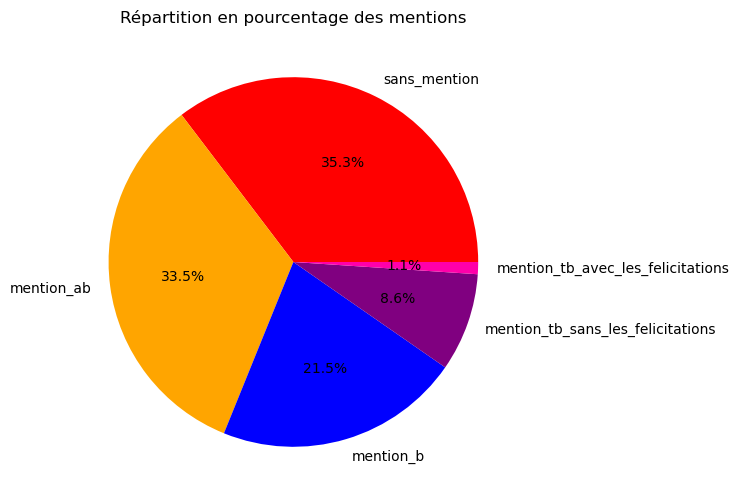

In [71]:
mentions_cols = [
    "mention_tb_avec_les_felicitations",
    "mention_tb_sans_les_felicitations",
    "mention_b",
    "mention_ab",
    "sans_mention"
]

df["total_mentions"] = df[mentions_cols].sum(axis=1)

global_mentions = df[mentions_cols].sum().sort_values(ascending=False)
global_mentions_pct = global_mentions / global_mentions.sum() * 100

colors_pie = {
    'mention_tb_avec_les_felicitations': '#FF00AA',
    'mention_tb_sans_les_felicitations': 'purple',
    'mention_b': 'blue',
    'mention_ab': 'orange',
    'sans_mention': 'red'
}

colors_pie = [colors_pie[col] for col in global_mentions.index]

print("Répartition globale des mentions ")
display(global_mentions)
display(global_mentions_pct)
#Répartition en pourcentage des mentions
plt.figure(figsize=(6,6))
plt.pie(global_mentions.values, labels=global_mentions.index, autopct="%1.1f%%", colors=colors_pie)
plt.title("Répartition en pourcentage des mentions")
plt.show()

## EDA focus sur les mentions

Suite au nombre restreint des admis avec mention tb avec les féliciations du jury, pour  
améliorer la lisibilité nous avons décider de joindre les mentions tb avec et sans  
féliciations.

In [72]:
df['mention_tb'] = df['mention_tb_sans_les_felicitations'] + df['mention_tb_avec_les_felicitations'] 

Liste utile pour les prochains graphiques :

In [73]:
admis_mention = [
    'mention_tb',
    'mention_b',
    'mention_ab', 
    'sans_mention',
]

percent_admis_mention = [
    '%_mention_tb',
    '%_mention_b',
    '%_mention_ab',
    '%_sans_mention' 
]

labels_mention = {
    'mention_tb': 'Très Bien',
    'mention_b': 'Bien',
    'mention_ab': 'Assez Bien',
    'sans_mention': 'Sans mention'
}

labels = {
    '%_mention_tb': 'Très Bien',
    '%_mention_b': 'Bien',
    '%_mention_ab': 'Assez Bien',
    '%_sans_mention': 'Sans mention'
}

colors_mention = {
    'mention_tb': '#FF00AA',
    'mention_b': 'blue',
    'mention_ab': 'orange',
    'sans_mention': 'red'
}

colors = {
    '%_mention_tb': '#FF00AA',
    '%_mention_b': 'blue',
    '%_mention_ab': 'orange',
    '%_sans_mention': 'red'
}

### Répartition des mentions par sexe

In [74]:
group_mention = df.groupby('sexe')[admis_mention].mean().reset_index()

cols = 2 
rows = (len(admis_mention) + cols - 1) // cols 
fig=go.Figure()
mention_sexe = make_subplots(
    rows=rows, 
    cols=cols, 
    subplot_titles=admis_mention, 
    shared_yaxes=True
)

for i,column in enumerate(admis_mention):
    row = i // cols + 1 
    col = i % cols + 1        
    mention_sexe.add_trace(
        go.Bar(
            x=group_mention['sexe'], 
            y=group_mention[column],
            marker=dict(color=colors_mention[column])
        ), 
        row=row, 
        col=col
    )

mention_sexe.update_layout(
    title=dict(text='Répartition des mentions par sexe', x=0.5, font=dict(size=20, color='blue')),
    showlegend=False
)
mention_sexe.update_yaxes(matches='y')
mention_sexe.update_annotations(yshift=10, font=dict(size=15, color='blue'))
mention_sexe.show()

### Répartition des mentions par académie

In [75]:
academie = df.groupby('academie')[admis_mention+['admis_totaux','presents']].sum().reset_index()

# Création de 4 colonnes pourcentage de chaque mention
academie['%_mention_tb'] = academie['mention_tb'] / academie['admis_totaux']
academie['%_mention_b'] = academie['mention_b'] / academie['admis_totaux']
academie['%_mention_ab'] = academie['mention_ab'] / academie['admis_totaux']
academie['%_sans_mention'] = academie['sans_mention'] / academie['admis_totaux']

fig_academie = go.Figure()
for i,column in enumerate(percent_admis_mention):
    fig_academie.add_trace(
        go.Bar(
            x=academie['academie'], 
            y=academie[column], 
            name=labels[column],
            marker_color=colors[column]
        )
    )
    
fig_academie.update_layout(
    title=dict(text='Répartition des mentions par academie', x=0.5, font=dict(size=20, color='blue')),
    autosize=False, 
    width=1500, 
    height=800
)
fig_academie.update_xaxes(type='category')
fig_academie.update_yaxes(tickformat=".1%")
fig_academie.show()


### Total admis par académie

In [76]:
admis_academie = go.Figure()
admis_academie.add_trace(go.Bar(x=academie['academie'], y=academie['admis_totaux'], name='admis'))
admis_academie.add_trace(go.Bar(x=academie['academie'], y=academie['presents'], name='présents'))
admis_academie.update_layout(title=dict(text='Répartition des admis par académie', x=0.5, font=dict(size=20, color='blue')))
admis_academie.update_layout(autosize=False, width=1500, height=600)
admis_academie.show()

### Classement des académies selon chaque mention

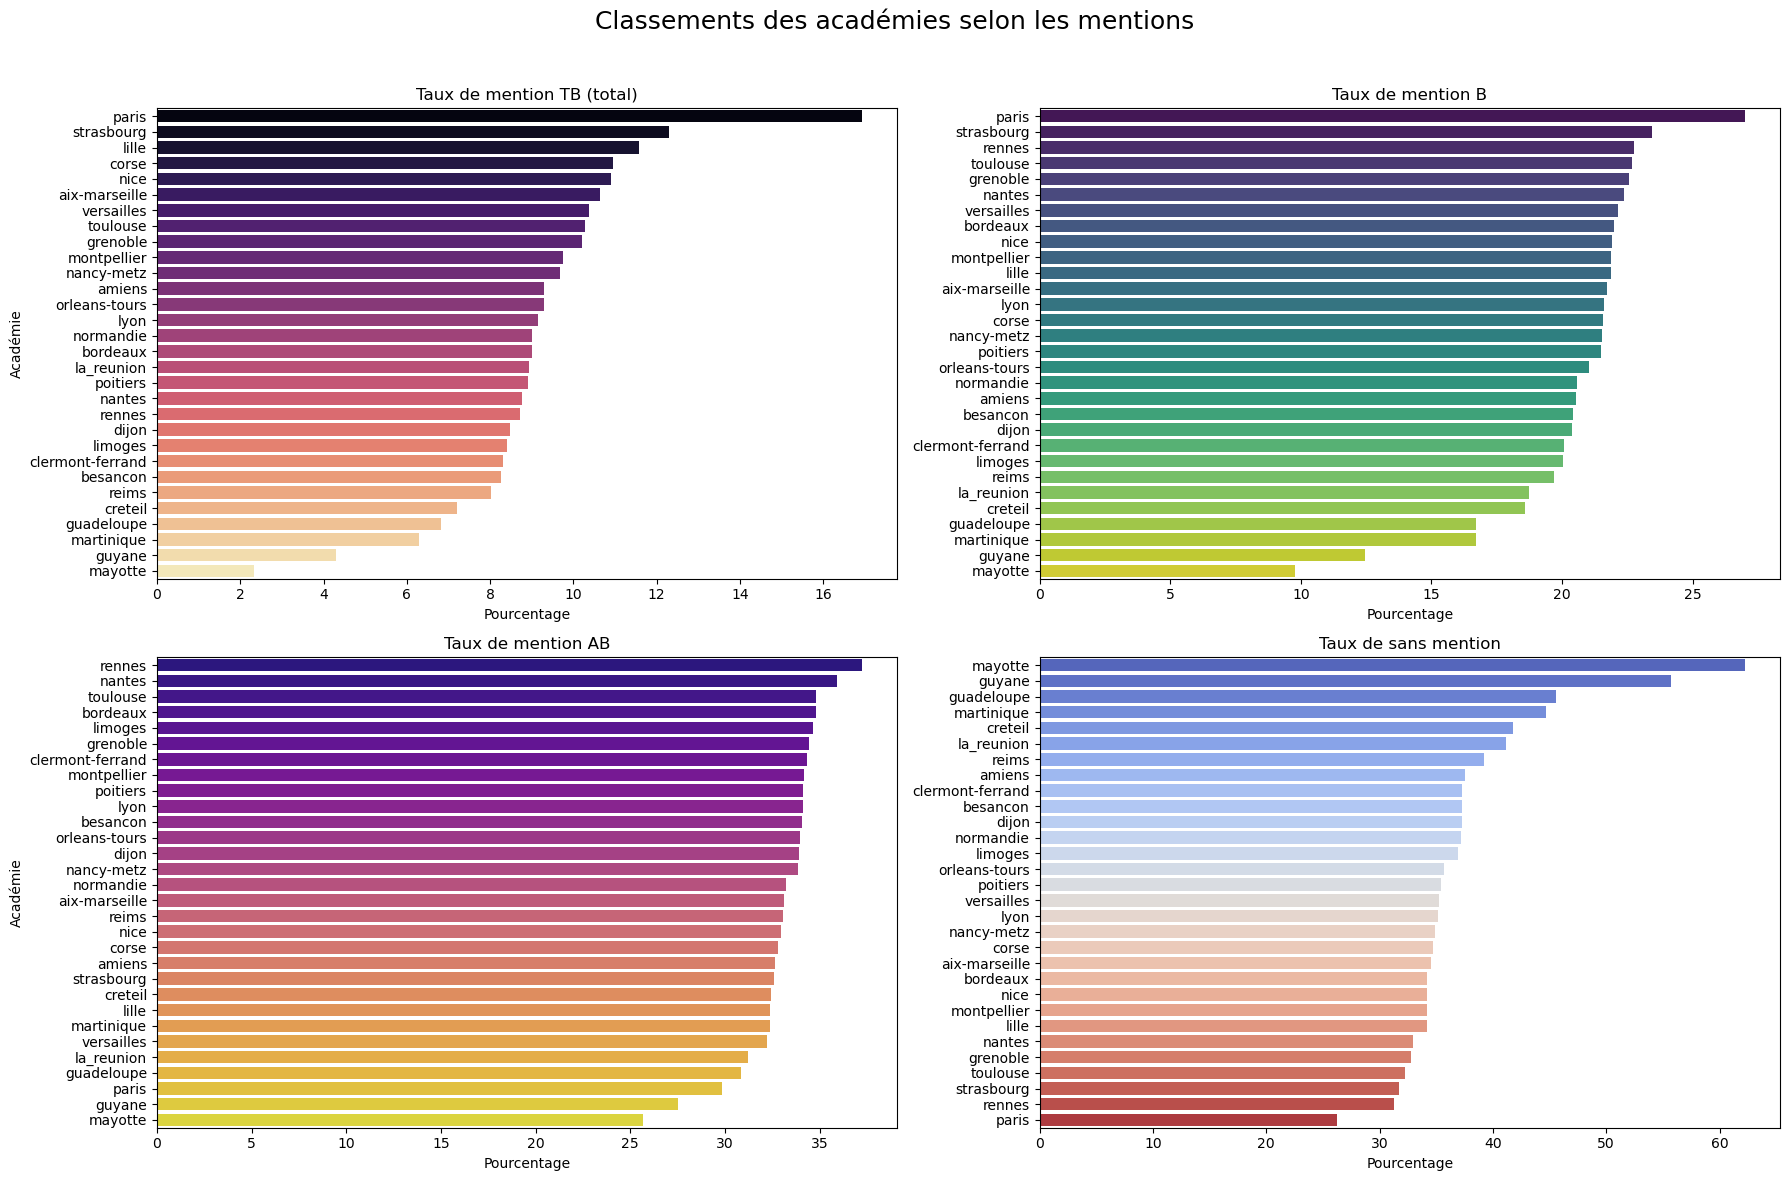

In [77]:
#Calcul des pourcentages par académie
acad = df.groupby("academie")[admis_mention].sum()
acad_pct = acad.div(acad.sum(axis=1), axis=0) * 100

#Classements
classement_tb = acad_pct["mention_tb"].sort_values(ascending=False)
classement_b  = acad_pct["mention_b"].sort_values(ascending=False)
classement_ab = acad_pct["mention_ab"].sort_values(ascending=False)
classement_sans = acad_pct["sans_mention"].sort_values(ascending=False)

#Création des subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Classements des académies selon les mentions", fontsize=18)

#Graphique 1 : TB total
sns.barplot(ax=axes[0,0], x=classement_tb.values, y=classement_tb.index, hue=classement_tb.index, palette="magma", legend=False)
axes[0,0].set_title("Taux de mention TB (total)")
axes[0,0].set_xlabel("Pourcentage")
axes[0,0].set_ylabel("Académie")

#Graphique 2 : Mention Bien
sns.barplot(ax=axes[0,1], x=classement_b.values, y=classement_b.index, hue=classement_b.index, palette="viridis", legend=False)
axes[0,1].set_title("Taux de mention B")
axes[0,1].set_xlabel("Pourcentage")
axes[0,1].set_ylabel("")

#Graphique 3 : Mention Assez Bien
sns.barplot(ax=axes[1,0], x=classement_ab.values, y=classement_ab.index, hue=classement_ab.index, palette="plasma", legend=False)
axes[1,0].set_title("Taux de mention AB")
axes[1,0].set_xlabel("Pourcentage")
axes[1,0].set_ylabel("Académie")

#Graphique 4 : Sans mention
sns.barplot(ax=axes[1,1], x=classement_sans.values, y=classement_sans.index, hue=classement_ab.index, palette="coolwarm", legend=False)
axes[1,1].set_title("Taux de sans mention")
axes[1,1].set_xlabel("Pourcentage")
axes[1,1].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Evolution temporelle du nombre de mention

In [78]:
df_session = df.groupby('session')[admis_mention+['admis_totaux']].sum().reset_index()

cols = 2 
rows = (len(admis_mention) + cols - 1) // cols

fig_session = go.Figure()
fig_session = make_subplots(rows, cols, subplot_titles= [labels_mention[col] for col in admis_mention])
for i,column in enumerate(admis_mention):
    row = i // cols + 1 
    col = i % cols + 1
    fig_session.add_trace(
        go.Scatter(
            x=df_session['session'],
            y=df_session[column],
            mode='lines+markers+text',
            texttemplate='%{y:.4s}',
            line=dict(color=colors_mention[column]),
            marker=dict(color=colors_mention[column]),
            textfont=dict(color=colors_mention[column])
        ),  
        row=row, 
        col=col
    )

fig_session.update_layout(
    title=dict(text='Evolution temporelle par mention', x=0.5, font=dict(size=20, color='blue')), 
    autosize=False, 
    width=1600, 
    height=800, 
    showlegend=False
)
fig_session.update_traces(
    textposition='top center', 
    cliponaxis=False, 
    textfont=dict(size=11)
)
fig_session.update_xaxes(type='category')
fig_session.update_annotations(yshift=10, font=dict(size=15, color='blue'))
fig_session.show()


### Evolution temporelle de la répartition des mentions

In [79]:
# Création de 4 colonnes pourcentage de chaque mention
df_session['%_mention_tb'] = df_session['mention_tb'] / df_session['admis_totaux']
df_session['%_mention_b'] = df_session['mention_b'] / df_session['admis_totaux']
df_session['%_mention_ab'] = df_session['mention_ab'] / df_session['admis_totaux']
df_session['%_sans_mention'] = df_session['sans_mention'] / df_session['admis_totaux']

cols = 2 
rows = (len(percent_admis_mention) + cols - 1) // cols  

fig_session = go.Figure()
fig_session = make_subplots(
    rows, 
    cols, 
    subplot_titles= [labels[col] for col in percent_admis_mention]
)

for i,column in enumerate(percent_admis_mention):
    row = i // cols + 1 
    col = i % cols + 1
    fig_session.add_trace(
        go.Scatter(
            x=df_session['session'],
            y=df_session[column], 
            mode='lines+markers+text', 
            texttemplate='%{y:.1%}',
            line=dict(color=colors[column]),
            marker=dict(color=colors[column]),
            textfont=dict(color=colors[column])
        ),
        row=row, 
        col=col
    )

fig_session.update_layout(
    title=dict(text='Evolution temporelle de la répartion des mentions', x=0.5, font=dict(size=20, color='blue')),
    autosize=False, 
    width=1600, 
    height=800, 
    showlegend=False
)
fig_session.update_xaxes(type='category')
fig_session.update_yaxes(tickformat=".0%")
fig_session.update_traces(textposition='top center', cliponaxis=False)
fig_session.update_annotations(yshift=10, font=dict(size=15, color='blue'))

fig_session.show()

## Conclusion de l'EDA

L'EDA révèle des disparités :  
- selon l'académie : Versailles et Créteil sont majoritaires    
- selon le statut du candidat : scolaire est très majoritaire  
- selon la voie : le bac général est très majoritaire  
- selon la série : là également la série général est très majoritaire

Classes déséquilibrées : mention très bien et mention bien sont minoritaires

Evolution des proportions pour les admis au fil des années 2021 à 2025 :  
- mention très bien stable (9.3 à 9.6%)  
- mention bien chute légèrement (22.7% à 21.4%)  
- mention assez bien chute (36.3% à 32.9%)
- sans mention augmente (31.6% à 36.1%)

L'année 2023 est une année pivot, à l'inverse les années 2024 et 2025, les répartitions sont stables.